# 06. Statistical Exploratory Data Analysis
## 📚 Learning Objectives

By completing this notebook, you will:
- Perform comprehensive statistical EDA
- Identify data distributions and patterns
- Detect correlations and relationships
- Generate statistical summaries and insights

## 🔗 Where this fits

**Builds on:** Course 03 (AIAT 113) — Unit 5, lessons 02 and 08 (statistical inference, p-values and confidence intervals) — the same statistics, now applied to profile a real dataset.

**Used later in:** Course 05 — Unit 4, lesson 07, where the same summary statistics are used to judge a model instead of a column.

---


## 🎯 The case: the housing dataset scikit-learn deleted, and the cap in the one that replaced it

For twenty years the default teaching dataset for regression was **Boston Housing**. Among
its thirteen columns was one called `B`, defined as *1000(Bk − 0.63)²*, where Bk is the
proportion of Black residents in the town. The transform is deliberately non-invertible,
and it was constructed on the premise that racial segregation raised house prices.
scikit-learn deprecated `load_boston` in version 1.0 and **removed it in 1.2**, with
documentation stating plainly that the variable encodes that assumption and that the
dataset should now be used only to *discuss* ethical problems in data science. The
maintainers recommended two replacements: **California Housing** and Ames.

This notebook loads California Housing. That is not a neutral default — it is the direct
consequence of somebody reading a column definition carefully.

**What goes wrong without statistical EDA — and it is in this file too.** You are about to
run `describe()` on the replacement dataset and find that `MedHouseVal` maxes out at
**exactly 5.00001** for **965 rows**, with **992 rows (4.8%)** sitting at or above 5.0 —
the count the cell below prints. That is not a cluster of identically priced
neighbourhoods. It is the 1990 US Census **top-coding** the value at $500,001: every
wealthier block group in California was recorded as the same number. A model trained on
this data can never predict above the cap, will be systematically wrong on the most
expensive 4.8% of California, and **nothing in the file says so**. Only reading the min and
max does.


## The Story

**BEFORE**: You have clean data but don't know how to explore and understand it systematically.

**AFTER**: You'll learn EDA techniques: statistical summaries, visualizations, and discovering insights from data!

**Why this matters**: Statistical Exploratory Data Analysis is essential for building complete, professional data science solutions!

---

**All concepts are explained in the code comments below - you can learn everything from this notebook alone!**

---

## 🔗 Building on Data Cleaning

**After cleaning data, what's next?**
- We've cleaned missing values and duplicates
- But we don't understand the data yet!
- We need to explore and discover patterns

**This notebook teaches EDA!**
- We'll learn **statistical summaries** - understand data distributions
- We'll learn **correlation analysis** - find relationships
- We'll learn **pattern detection** - discover insights
- We'll learn **data profiling** - comprehensive understanding

**This is how you understand your data before modeling!**

---

## Learning Objectives
1. Generate statistical summaries (mean, median, std, quartiles)
2. Analyze correlations between variables
3. Identify data distributions and patterns
4. Create comprehensive data profiles

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Dataset
- pandas, scipy/stats, viz libraries

**Outputs:** What you'll see when you run the cells

- Statistical summaries
- Plots and tables

---

In [1]:
# WHAT: Import libraries and preview the four statistical-EDA topics.
# WHY: Statistical EDA quantifies what plots show - numbers and pictures should always confirm each other.

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries imported!")
print("\n📚 This notebook covers:")
print("   - Statistical summaries")
print("   - Correlation analysis")
print("   - Distribution analysis")
print("   - Data profiling")

✅ Libraries imported!

📚 This notebook covers:
   - Statistical summaries
   - Correlation analysis
   - Distribution analysis
   - Data profiling


In [2]:
# WHAT: Load the real California Housing census data and keep four numeric columns to profile.
# WHY: Statistical EDA is only worth doing on data you did not design - real columns come with skew, caps and surprises.

# Step 2: Load a real dataset
# 20,640 California census block groups from the 1990 US census, distributed with
# scikit-learn so it works offline. Every row is a real neighbourhood.
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
full = housing.frame

# Four numeric columns, chosen so the 2x2 plot grid below shows one of each shape.
df = full[['MedInc', 'HouseAge', 'AveRooms', 'MedHouseVal']].copy()

print(f"Dataset shape: {df.shape}")
print("\nWhat each column means (from the dataset documentation):")
print("  MedInc      median household income in the block group (tens of thousands $)")
print("  HouseAge    median age of the houses (years)")
print("  AveRooms    average number of rooms per household")
print("  MedHouseVal median house value (hundreds of thousands $) - the target")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing values: {df.isnull().sum().sum()}"
      " - this census extract is complete, which you only know because you checked.")


Dataset shape: (20640, 4)

What each column means (from the dataset documentation):
  MedInc      median household income in the block group (tens of thousands $)
  HouseAge    median age of the houses (years)
  AveRooms    average number of rooms per household
  MedHouseVal median house value (hundreds of thousands $) - the target

First 5 rows:
   MedInc  HouseAge  AveRooms  MedHouseVal
0  8.3252      41.0  6.984127        4.526
1  8.3014      21.0  6.238137        3.585
2  7.2574      52.0  8.288136        3.521
3  5.6431      52.0  5.817352        3.413
4  3.8462      52.0  6.281853        3.422

Missing values: 0 - this census extract is complete, which you only know because you checked.


In [3]:
# WHAT: Produce describe() output plus per-column mean/median/std/min/max.
# WHY: Comparing mean vs median is a quick skew check - a big gap means outliers or a long tail.

# Step 3: Statistical Summary
print("=" * 70)
print("1. Statistical Summary")
print("=" * 70)

print("\nDescriptive Statistics:")
print(df.describe())

print("\n\nKey Statistics:")
for col in df.columns:
    print(f"\n{col}:")
    print(f"  Mean: {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std: {df[col].std():.2f}")
    print(f"  Min: {df[col].min():.2f}")
    print(f"  Max: {df[col].max():.2f}")

print("\n\n⚠ Two things describe() just told you about this REAL data:")
print(f"  1. AveRooms max is {df['AveRooms'].max():.1f} rooms per household, against a")
print(f"     median of {df['AveRooms'].median():.1f}. Those are real block groups -")
print("     mostly tiny, near-empty ones where the average explodes.")
capped = int((df['MedHouseVal'] >= 5.0).sum())
print(f"  2. MedHouseVal maxes out at exactly {df['MedHouseVal'].max():.5f} for"
      f" {capped:,} rows")
print(f"     ({capped / len(df) * 100:.1f}%). The census CENSORED the value at")
print("     $500,001 - every more expensive neighbourhood was recorded as that.")
print("     A model trained on this can never predict above the cap. Nothing in")
print("     the file warns you; only reading the min/max does.")


1. Statistical Summary

Descriptive Statistics:
             MedInc      HouseAge      AveRooms   MedHouseVal
count  20640.000000  20640.000000  20640.000000  20640.000000
mean       3.870671     28.639486      5.429000      2.068558
std        1.899822     12.585558      2.474173      1.153956
min        0.499900      1.000000      0.846154      0.149990
25%        2.563400     18.000000      4.440716      1.196000
50%        3.534800     29.000000      5.229129      1.797000
75%        4.743250     37.000000      6.052381      2.647250
max       15.000100     52.000000    141.909091      5.000010


Key Statistics:

MedInc:
  Mean: 3.87
  Median: 3.53
  Std: 1.90
  Min: 0.50
  Max: 15.00

HouseAge:
  Mean: 28.64
  Median: 29.00
  Std: 12.59
  Min: 1.00
  Max: 52.00

AveRooms:
  Mean: 5.43
  Median: 5.23
  Std: 2.47
  Min: 0.85
  Max: 141.91

MedHouseVal:
  Mean: 2.07
  Median: 1.80
  Std: 1.15
  Min: 0.15
  Max: 5.00


⚠ Two things describe() just told you about this REAL data:
  1. A

## 💬 Discuss

`describe()` just surfaced two problems that no amount of modelling would have fixed:
**`AveRooms` reaches 141.9 rooms per household** against a median of 5.2 (skewness 20.7,
kurtosis 879), and **`MedHouseVal` is censored at the top, with 992 rows (4.8%) at or above 5.0 and 965 of
them at exactly 5.00001**.

1. The 141.9-room block groups are real — tiny, near-empty areas where an average explodes.
   Are they outliers to remove, a signal to keep, or evidence that `AveRooms` is the wrong
   feature? Take a position, then say what you would compute instead if you kept the
   underlying information.
2. The censoring cap means your model's error on expensive neighbourhoods is guaranteed and
   unmeasurable from this data. If a client in Riyadh or Jeddah asked you to build the same
   model on local property records, what one question would you ask about how the target was
   recorded — before you wrote any code?
3. `MedInc` and `MedHouseVal` correlate at **0.688**, and the notebook says income does not
   *cause* house prices; both are driven by location. Suppose a policy analyst reads this
   and proposes raising incomes to raise house values. What is the fastest honest way to
   show them the argument does not follow from this number?



2. Correlation Analysis

Correlation Matrix:
               MedInc  HouseAge  AveRooms  MedHouseVal
MedInc       1.000000 -0.119034  0.326895     0.688075
HouseAge    -0.119034  1.000000 -0.153277     0.105623
AveRooms     0.326895 -0.153277  1.000000     0.151948
MedHouseVal  0.688075  0.105623  0.151948     1.000000


Strong Correlations (|r| > 0.5):
  MedInc ↔ MedHouseVal: 0.688


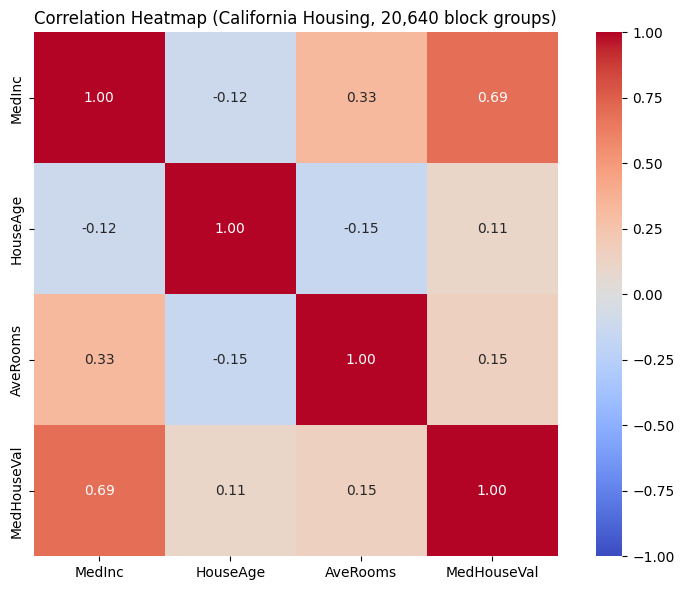

✓ Correlation heatmap plotted

💡 Reading the result honestly:
  - Income and house value move together strongly (r = 0.688). Richer areas,
    pricier houses. That is real, and it is the single most useful predictor.
  - AveRooms vs MedHouseVal is only 0.152 - bigger houses do NOT
    reliably mean pricier areas, because the outlier block groups distort it.
  - Correlation is not causation: income does not CAUSE house prices here;
    both are driven by where in California the block group sits.


In [4]:
# WHAT: Compute the correlation matrix, list strong pairs (|r| > 0.5), and draw a heatmap.
# WHY: Correlations point to candidate predictors and redundant features - but remember correlation is not causation.

# Step 4: Correlation Analysis
print("\n" + "=" * 70)
print("2. Correlation Analysis")
print("=" * 70)

correlation_matrix = df.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)

print("\n\nStrong Correlations (|r| > 0.5):")
n_strong = 0
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr = correlation_matrix.iloc[i, j]
        if abs(corr) > 0.5:
            col1 = correlation_matrix.columns[i]
            col2 = correlation_matrix.columns[j]
            print(f"  {col1} ↔ {col2}: {corr:.3f}")
            n_strong += 1
if n_strong == 0:
    print("  (none above the 0.5 threshold)")

# Visualize the whole matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True)
plt.title('Correlation Heatmap (California Housing, 20,640 block groups)')
plt.tight_layout()
plt.show()
print("✓ Correlation heatmap plotted")
print("\n💡 Reading the result honestly:")
print(f"  - Income and house value move together strongly"
      f" (r = {correlation_matrix.loc['MedInc', 'MedHouseVal']:.3f}). Richer areas,")
print("    pricier houses. That is real, and it is the single most useful predictor.")
print(f"  - AveRooms vs MedHouseVal is only"
      f" {correlation_matrix.loc['AveRooms', 'MedHouseVal']:.3f} - bigger houses do NOT")
print("    reliably mean pricier areas, because the outlier block groups distort it.")
print("  - Correlation is not causation: income does not CAUSE house prices here;")
print("    both are driven by where in California the block group sits.")


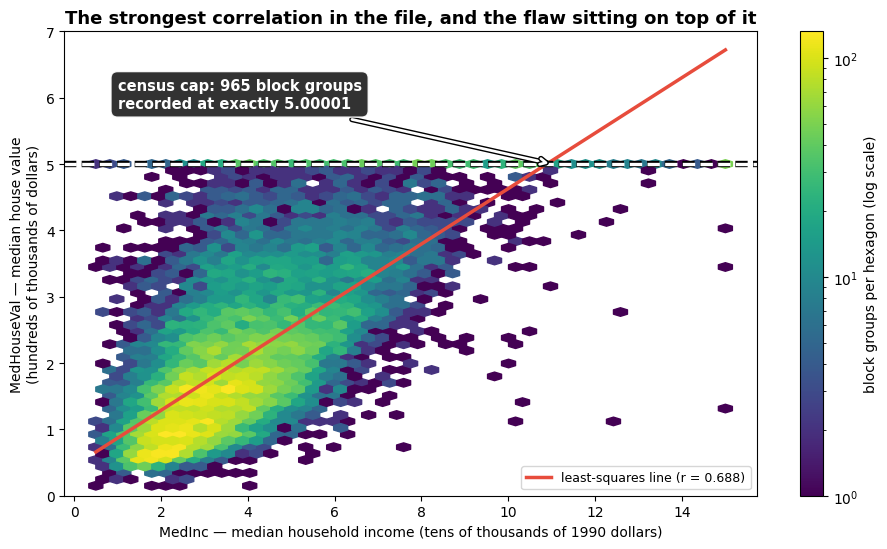

Rows sitting exactly on the cap: 965 of 20,640 (4.7%)
Rows at or above 5.0:            992
Every one of those neighbourhoods was worth AT LEAST $500,001 in 1990. The
census did not record how much more. No model can learn what was never written
down, and no error metric computed on this file will tell you it is missing.


In [5]:
# WHAT: Plot the strongest correlation as a picture, on all 20,640 block groups.
# WHY: r = 0.688 is a single number summarising 20,640 points. The number cannot tell you
#      that the top of the data is a straight line of censored values - the picture can.

cap_value = df['MedHouseVal'].max()
n_at_cap = int((df['MedHouseVal'] >= cap_value - 1e-9).sum())
r = df['MedInc'].corr(df['MedHouseVal'])

fig, ax = plt.subplots(figsize=(9.5, 5.6))
# 20,640 dots would be a solid blob, so bin them into hexagons and colour by count.
hb = ax.hexbin(df['MedInc'], df['MedHouseVal'], gridsize=45, cmap='viridis',
               mincnt=1, bins='log')
fig.colorbar(hb, ax=ax, label='block groups per hexagon (log scale)')

# The least-squares line is what r = 0.688 is measuring.
slope, intercept = np.polyfit(df['MedInc'], df['MedHouseVal'], 1)
xs = np.linspace(df['MedInc'].min(), df['MedInc'].max(), 50)
ax.plot(xs, slope * xs + intercept, color='#e74c3c', linewidth=2.5,
        label=f'least-squares line (r = {r:.3f})')

# A plain white line disappears into the pale hexagons, so give it a dark halo,
# and park the label in the empty space above the cap rather than on top of the data.
import matplotlib.patheffects as pe
cap_line = ax.axhline(cap_value, color='white', linestyle='--', linewidth=2.4)
cap_line.set_path_effects([pe.Stroke(linewidth=4.6, foreground='black'), pe.Normal()])
ax.annotate(f'census cap: {n_at_cap:,} block groups\nrecorded at exactly {cap_value:.5f}',
            xy=(11.0, cap_value), xytext=(1.0, 6.05), fontsize=10.5, color='white',
            weight='bold', va='center',
            bbox=dict(boxstyle='round,pad=0.45', facecolor='#1b1b1b', alpha=0.9,
                      edgecolor='white'),
            arrowprops=dict(arrowstyle='->', color='white', lw=2.0,
                            shrinkA=6, shrinkB=2,
                            path_effects=[pe.Stroke(linewidth=4.0, foreground='black'),
                                          pe.Normal()]))
ax.set_ylim(0, 7.0)
ax.set_xlabel('MedInc — median household income (tens of thousands of 1990 dollars)')
ax.set_ylabel('MedHouseVal — median house value\n(hundreds of thousands of dollars)')
ax.set_title('The strongest correlation in the file, and the flaw sitting on top of it',
             fontsize=13, weight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Rows sitting exactly on the cap: {n_at_cap:,} of {len(df):,}"
      f" ({n_at_cap / len(df):.1%})")
print(f"Rows at or above 5.0:            {(df['MedHouseVal'] >= 5.0).sum():,}")
print("Every one of those neighbourhoods was worth AT LEAST $500,001 in 1990. The")
print("census did not record how much more. No model can learn what was never written")
print("down, and no error metric computed on this file will tell you it is missing.")


**Read the figure.** Each hexagon holds the block groups that fall in that patch of the
plot, coloured by how many (log scale, so a bright cell is hundreds of neighbourhoods). The
bright mass runs diagonally up and to the right: richer areas do have pricier houses, and
the red least-squares line is exactly what the number **r = 0.688** in the heatmap was
summarising.

Now look at the top edge. There is a hard, bright horizontal stripe running the full width
of the plot at 5.00001 — **965 block groups recorded at the identical value**, at every
income level from the poorest to the richest. Real house prices do not do that. That stripe
is the 1990 census's $500,001 ceiling, and it is the single most important thing on this
page: any model you fit here is being taught that a neighbourhood with a median income of
$150,000 has the same house value as one at $80,000, because both were truncated to the same
number.

One more thing worth pointing at in class: follow the red line to the right-hand edge. It
keeps climbing past the cap and finishes above 6.5 — the fitted model wants to predict values
this file was never permitted to contain, and nothing in the data can contradict it.

The correlation coefficient could not have told you any of this. The scatter tells you in one
look. That is the whole argument for plotting a relationship before you trust a number that
claims to summarise it.



3. Distribution Analysis

Skewness (measure of asymmetry):
  MedInc: 1.647
    → Highly skewed!
  HouseAge: 0.060
  AveRooms: 20.698
    → Highly skewed!
  MedHouseVal: 0.978


Kurtosis (measure of tail heaviness):
  MedInc: 4.953
  HouseAge: -0.801
  AveRooms: 879.353
  MedHouseVal: 0.328


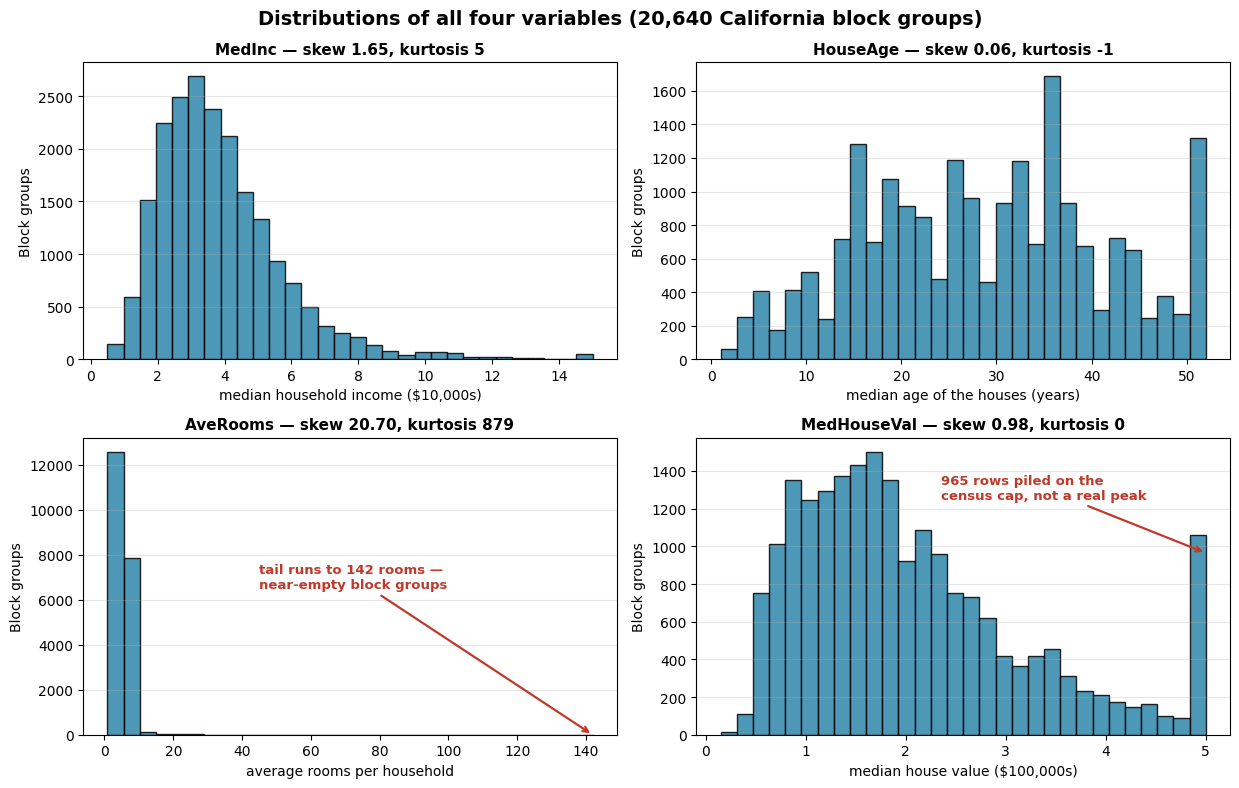

✓ Distribution histograms plotted

💡 What the shape statistics are telling you to DO:
  - AveRooms: skew 20.7, kurtosis 879. That is not a bell curve with a few strays;
    it is a spike with a very long tail. Transform it (Example 3's log1p)
    or cap it before feeding it to a linear model.
  - HouseAge: skew 0.06, nearly symmetric - leave it alone.
  - The histogram of MedHouseVal has a visible bar at the far right: that is
    the censoring cap, not a genuine cluster of homes worth exactly the same.

Summary

What this EDA found (computed above):
  - describe() summarized all 4 numeric variables
  - Strongest relationship: MedInc ↔ MedHouseVal
    (r = 0.688) - visible in the heatmap
  - Skewness/kurtosis quantified each distribution's shape,
    confirmed visually by the histograms
  - Two data-quality findings that only reading the numbers exposed:
    the censoring cap on MedHouseVal and the extreme tail on AveRooms

✅ Statistical EDA - summaries, plots, and insights complete!


In [6]:
# WHAT: Measure skewness and kurtosis per column and plot every distribution.
# WHY: Shape statistics tell you which columns need transforming before modeling (see Example 3's log transform).

# Step 5: Distribution Analysis
print("\n" + "=" * 70)
print("3. Distribution Analysis")
print("=" * 70)

print("\nSkewness (measure of asymmetry):")
for col in df.select_dtypes(include=[np.number]).columns:
    skew = df[col].skew()
    print(f"  {col}: {skew:.3f}")
    if abs(skew) > 1:
        print(f"    → Highly skewed!")

print("\n\nKurtosis (measure of tail heaviness):")
for col in df.select_dtypes(include=[np.number]).columns:
    kurt = df[col].kurtosis()
    print(f"  {col}: {kurt:.3f}")

# Visualize every distribution. Units on every x axis, and the two data-quality
# findings marked on the panels where they actually appear.
units = {
    'MedInc': 'median household income ($10,000s)',
    'HouseAge': 'median age of the houses (years)',
    'AveRooms': 'average rooms per household',
    'MedHouseVal': 'median house value ($100,000s)',
}
fig, axes = plt.subplots(2, 2, figsize=(12.5, 8))
for ax, col in zip(axes.ravel(), df.columns):
    ax.hist(df[col], bins=30, color='#2E86AB', edgecolor='black', alpha=0.85)
    ax.set_title(f'{col} — skew {df[col].skew():.2f}, kurtosis {df[col].kurtosis():.0f}',
                 fontsize=11, weight='bold')
    ax.set_xlabel(units[col])
    ax.set_ylabel('Block groups')
    ax.grid(True, alpha=0.3, axis='y')

# Mark the long tail that the kurtosis of 879 is describing.
ax_rooms = axes.ravel()[list(df.columns).index('AveRooms')]
ax_rooms.annotate(f"tail runs to {df['AveRooms'].max():.0f} rooms —\nnear-empty block groups",
                  xy=(df['AveRooms'].max(), 0), xytext=(45, 6500), fontsize=9.5,
                  color='#c0392b', weight='bold',
                  arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.6))

# Mark the censoring cap - the bar on the right is an artefact, not a cluster of homes.
ax_val = axes.ravel()[list(df.columns).index('MedHouseVal')]
n_cap = int((df['MedHouseVal'] >= df['MedHouseVal'].max() - 1e-9).sum())
ax_val.annotate(f'{n_cap:,} rows piled on the\ncensus cap, not a real peak',
                xy=(df['MedHouseVal'].max(), n_cap), xytext=(2.35, 1250), fontsize=9.5,
                color='#c0392b', weight='bold',
                arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.6))

plt.suptitle('Distributions of all four variables (20,640 California block groups)',
             fontsize=14, weight='bold')
plt.tight_layout()
plt.show()
print("✓ Distribution histograms plotted")
print("\n💡 What the shape statistics are telling you to DO:")
print(f"  - AveRooms: skew {df['AveRooms'].skew():.1f}, kurtosis"
      f" {df['AveRooms'].kurtosis():.0f}. That is not a bell curve with a few strays;")
print("    it is a spike with a very long tail. Transform it (Example 3's log1p)")
print("    or cap it before feeding it to a linear model.")
print(f"  - HouseAge: skew {df['HouseAge'].skew():.2f}, nearly symmetric - leave it alone.")
print("  - The histogram of MedHouseVal has a visible bar at the far right: that is")
print("    the censoring cap, not a genuine cluster of homes worth exactly the same.")

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
strongest = correlation_matrix.where(~np.eye(len(correlation_matrix), dtype=bool)).abs().stack().idxmax()
print(f"""
What this EDA found (computed above):
  - describe() summarized all {df.shape[1]} numeric variables
  - Strongest relationship: {strongest[0]} ↔ {strongest[1]}
    (r = {correlation_matrix.loc[strongest[0], strongest[1]]:.3f}) - visible in the heatmap
  - Skewness/kurtosis quantified each distribution's shape,
    confirmed visually by the histograms
  - Two data-quality findings that only reading the numbers exposed:
    the censoring cap on MedHouseVal and the extreme tail on AveRooms
""")
print("✅ Statistical EDA - summaries, plots, and insights complete!")


**Read the figure.** Four columns from one file, four different shapes — and the shape is
what tells you what to do next.

`MedInc` (skew 1.65) is a lopsided hump with a thin right tail: ordinary income data. Look at
its far right edge, though: a small isolated bar at 15. That is 51 block groups censored at
$150,001, the same trick the target column plays on a larger scale. `HouseAge` (skew 0.06)
is nearly flat and nearly symmetric — except for the tall bar at the right, which is 1,273
block groups recorded as "52 years", the oldest value the 1990 census would write down.

`AveRooms` (skew 20.70, kurtosis 879) is the extreme case: one narrow spike near 5 rooms and
then effectively nothing, with the axis dragged out to 142 by a handful of near-empty block
groups where an average explodes. That is what a kurtosis of 879 looks like, and it is the
column the log transform from lesson 03 exists for.

`MedHouseVal` is the one to stare at. The bars decline steadily toward the right — and then
one leaps back up at the far edge, marked by the red arrow. That bar is not a cluster of
neighbourhoods that happen to be worth the same; it is 965 different neighbourhoods whose
true values were thrown away and replaced by the cap. **A histogram with a bar standing at
the extreme edge of its axis is one of the most reliable warning signs in data cleaning: it
usually means a limit, not a peak.** Three of these four columns carry one.


## ⚠️ Where this breaks

- **`describe()` describes; it does not warn.** The censoring cap, the 141.9-room block
  groups and the 1990 vintage of this census are all invisible unless a human reads the
  numbers against a mental model of what is possible. Automated profiling tools produce the
  same table faster and are equally silent.
- **Pearson's r assumes a linear relationship between two roughly symmetric variables.**
  `AveRooms` has skewness 20.7 and kurtosis 879; its correlation of 0.152 with house value
  is dominated by a handful of extreme block groups. Use Spearman's rank correlation on
  columns shaped like that, and look at the scatter before quoting either.
- **Correlation is not causation, and this dataset is a textbook confounder case.** Income
  and house value move together at 0.688 because both are driven by *where in California
  the block group is*. Latitude and longitude are in the full dataset and would absorb much
  of that relationship — a variable you did not include is doing the work you are crediting
  to one you did.
- **The assumption that must hold: the target means what you think it means.** It does not
  here. Top-coded at $500,001, `MedHouseVal` is not "the median house value" for 4.8% of
  rows — it is "at least $500,001". That is a *censored* variable, and the honest tools for
  it are survival-style or Tobit models, not ordinary least squares.
- **The data is from 1990.** Any conclusion about California housing is a conclusion about
  California in 1990. That is fine for learning the method and worthless as advice.
- **Cheaper alternative:** when the goal is only "does anything look wrong before I model?",
  a plot of every column plus `min`/`max`/`n_unique` catches more real defects in thirty
  seconds than a correlation matrix does — the two defects in this notebook were both
  found by min/max, not by any correlation.


## 📚 References

1. Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
2. Anscombe, F. J. (1973). *Graphs in Statistical Analysis*. The American Statistician, 27(1), 17-21. <https://doi.org/10.1080/00031305.1973.10478966>
3. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning*, 2nd ed. Springer. <https://www.statlearning.com>
4. Zhang, S., Fan, J., Fan, M., Li, G., & Du, X. (2025). *DeepAnalyze: Agentic Large Language Models for Autonomous Data Science*. arXiv:2510.16872. <https://arxiv.org/abs/2510.16872>
5. Jing, L., Huang, Z., Wang, X., et al. (2024). *DSBench: How Far Are Data Science Agents from Becoming Data Science Experts?*. arXiv:2409.07703. <https://arxiv.org/abs/2409.07703>
